# Gradient Boosting Model: XGBoost

In [1]:
# Settings

import os
import json
import pandas as pd
import numpy as np
import torch
import optuna
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
from src.utils.data_fetch import DataLoader
from src.utils.model_eval.evaluation import evaluate_predictions
from src.visualisations.viz_model import plot_confusion_matrix


SEED = 1234
TUNE = False
TUNE_SAVE = True
TUNE_METRIC = 'recall' # recall/auc
TUNE_OUTPUT = f'xgboost_params_{TUNE_METRIC}.json'
MODEL_OUTPUT = f'xgboost_model_{TUNE_METRIC}.json'
MODEL_SAVE = True
MODEL_LOAD = True
N_TRIALS = 50

D:\Projects\datasci_207_project\ds207_final_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data
X_train, X_val, X_test, y_train, y_val, y_test = DataLoader().fetch_data(version='final_onehot')

# Remove ID and drug (not grouped) columns
id_cols = [c for c in X_train.columns if 'encounter_id' in c or 'patient_nbr' in c]
drug_cols = [c for c in X_train.columns if 'prescript' in c and (('Up' in c) or ('Down' in c) or ('Steady' in c) or ('No' in c))]
drug_group_cols = [c for c in X_train.columns if 'prescript' in c and (('prescribed' in c) or ('change' in c))]
drop_cols = id_cols + drug_cols
X_train = X_train.drop(drop_cols, axis=1)
X_val = X_val.drop(drop_cols, axis=1)
X_test = X_test.drop(drop_cols, axis=1)

# Modify special characters in column names for xgboost tuning
cols_update = [c.replace('[', '(').replace(')', ')').replace('<', 'lt').replace('>', 'gt') for c in X_train.columns]
X_train.columns = cols_update
X_val.columns = cols_update
X_test.columns = cols_update

# Convert input to tensors for gpu
X_train_t = torch.tensor(X_train.values, dtype=torch.float32, device='cuda')
X_val_t = torch.tensor(X_val.values, dtype=torch.float32, device='cuda')
y_train_t = torch.tensor(y_train.values, dtype=torch.float32, device='cuda')
y_val_t = torch.tensor(y_val.values, dtype=torch.float32, device='cuda')

Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_test.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_test.csv 
Data imported succesfully from paths


### Hyperparameter tuning

- Use the same evaluation score metric (recall) for hyperparameter tuning.
- Suggest overfitting using a 10% discrepancy between training and validation accuracy.
- If overfitting is suggested, force to metric to 0 to skip the trail output.

In [3]:
# Define objective function

def objective(trial):
    """
    Hyperparameter tuning objective function.

    Args:
        trial: Tuning hyperparameter trial

    Returns:
        Assessment score
    """
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators'      , 300  , 2000),
        'max_depth'       : trial.suggest_int('max_depth'         , 5    , 15),
        # 'max_bin'         : trial.suggest_int('max_bin'           , 128  , 512), # not effective
        'min_child_weight': trial.suggest_float('min_child_weight', 10   , 100),
        'subsample'       : trial.suggest_float('subsample'       , 0.2  , 1.0),
        'learning_rate'   : trial.suggest_float('learning_rate'   , 0.002, 0.5  , log           = True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1  , 1.0),
        'gamma'           : trial.suggest_float('gamma'           , 0    , 10),
        'reg_alpha'       : trial.suggest_float('reg_alpha'       , 1e-8 , 10   , log           = True),
        'reg_lambda'      : trial.suggest_float('reg_lambda'      , 1e-8 , 10   , log           = True),
        'objective'       : 'binary:logistic',
        'eval_metric'     : 'auc',
        'tree_method'     : 'hist',
        'device'          : 'cuda',
        'random_state'    : SEED,
        'n_jobs'          : -1,
    }

    # Fit the model
    model = XGBClassifier(**params)
    model.fit(X_train_t,
              y_train_t,
              eval_set=[(X_val_t, y_val_t)],
              verbose=False
              )

    # Metric: recall
    if TUNE_METRIC == 'recall':

        y_pred_train = model.predict(X_train_t)
        y_pred_val = model.predict(X_val_t)

        # traing set
        recall_tr, _, _, acc_tr, _ = \
        evaluate_predictions(true_values = y_train,
                             predictions = y_pred_train,
                             print_class_report = False)

        # validation set:
        recall_vl, _, _, acc_vl , _ = \
        evaluate_predictions(true_values = y_val,
                             predictions = y_pred_val,
                             print_class_report = False)

        # Force the trial to output minimum score if overfits
        if acc_tr - acc_vl > 0.10:  # >10% gap suggests overfitting
            print(f"Warning: Possible overfitting")
            return 0

        return recall_vl

    # Metric: auc
    elif TUNE_METRIC == 'auc':
        y_pred_train = model.predict_proba(X_train_t)[:, 1]
        y_pred_val = model.predict_proba(X_val_t)[:, 1]

        # Force the trial to output minimum score if overfits
        acc_train = accuracy_score(y_train, y_pred_train)
        acc_val = accuracy_score(y_val, y_pred_val)
        if acc_train - acc_val > 0.10:  # >10% gap suggests overfitting
            print(f"Warning: Possible overfitting")
            return 0

        score = roc_auc_score(y_val, y_pred_val)
        return score


In [4]:
# Perform tuning and save the best parameters
if TUNE:
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=N_TRIALS, n_jobs=-1)
    print('Best Value:', study.best_value)
    print('Best Parameters:', study.best_params)

    if TUNE_SAVE:
        # Save output
        print('Save parameters to file:', TUNE_OUTPUT)
        with open(os.path.join(os.getcwd(), TUNE_OUTPUT), 'w') as f:
            json.dump(study.best_params, f)

### Model training with the best parameters

In [5]:
# Fit model
if not MODEL_LOAD:

    # Load parameters
    with open(os.path.join(os.getcwd(), TUNE_OUTPUT), 'r') as f:
        best_params = json.load(f)

    # Fit the model
    model = XGBClassifier(**best_params)
    model.fit(X_train,
              y_train,
              eval_set=[(X_val, y_val)],
              verbose=False
              )

    # Save model
    if MODEL_SAVE:
       model.save_model(os.path.join(os.getcwd(), MODEL_OUTPUT))

# Load model
else:
    model = XGBClassifier()
    model.load_model(os.path.join(os.getcwd(), MODEL_OUTPUT))

              precision    recall  f1-score   support

           0       0.64      0.70      0.67     10506
           1       0.62      0.56      0.59      9363

    accuracy                           0.63     19869
   macro avg       0.63      0.63      0.63     19869
weighted avg       0.63      0.63      0.63     19869



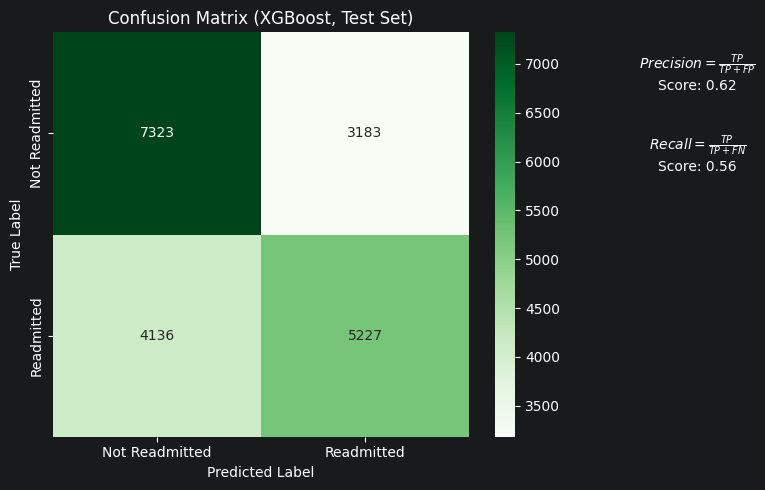

In [6]:
# Predict outcomes
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

recall_ts, _, _, _, _ = \
evaluate_predictions(true_values=y_test,
                     predictions=y_pred_test,
                     print_class_report=True)

# confusion matrix-validation set
results_cm_test = plot_confusion_matrix(y_test,
                                        y_pred_test, #test set predictions
                                        class_names=['Not Readmitted', 'Readmitted'],
                                        fig_size=(8,5),
                                        title='Confusion Matrix (XGBoost, Test Set)',
                                        colour_map='Greens'
                                        )